In [1]:
import biom
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from functools import partial


In [2]:
def get_phylum(otu_id, meta, i):
    
    tax = meta['taxonomy']
    if len(tax) >= i+1 and tax[i] != '':
        return tax[i]
    return 'Unknown'

def biom_to_csv_phylum(path, i):
    
    table = biom.load_table(path)
    
    table_phylum = table.collapse(
    partial(get_phylum, i=i), 
    axis='observation',
    norm=False
    )
    
    df_phylum = table_phylum.to_dataframe(dense=True)
    
    X_sb = df_phylum.T
    
    return X_sb

def entropy(df):
    
    xi0 = df.div(df.sum(axis=1), axis=0)
    xi1 = df.div(df.sum(axis=0), axis=1)
    
    p0 = xi0[xi0>0]
    p1 = xi1[xi1>0]
    
    Hp = -np.sum(p0 * np.log(p0), axis=0)
    Hs = -np.sum(p1 * np.log(p1), axis=1)
    
    return Hp, Hs
  

In [3]:
taxo = ['phylum', 'clas', 'order', 'family', 'genus']
X_sb = {}

for i in range(len(taxo)):
    X_sb[taxo[i]] = biom_to_csv_phylum('emp_deblur_150bp.release1.biom', i+1)

In [4]:
X_sb['phylum'] = X_sb['phylum'].drop(columns='Unknown')
X_sb['clas']   = X_sb['clas'].drop(columns='Unknown')
X_sb['order']  = X_sb['order'].drop(columns='Unknown')
X_sb['family'] = X_sb['family'].drop(columns='Unknown')
X_sb['genus']  = X_sb['genus'].drop(columns=['g__', 'Unknown'])

In [5]:
Hp  = {}
Hsp = {}

for i in range(len(taxo)):
    Hp[taxo[i]], Hsp[taxo[i]] = entropy(X_sb[taxo[i]])    

In [6]:
func_table = biom.load_table('functional_table_final.biom')
df_func = func_table.to_dataframe(dense=True)
X_sf = df_func.T

In [7]:
Hf, Hsf = entropy(X_sf)

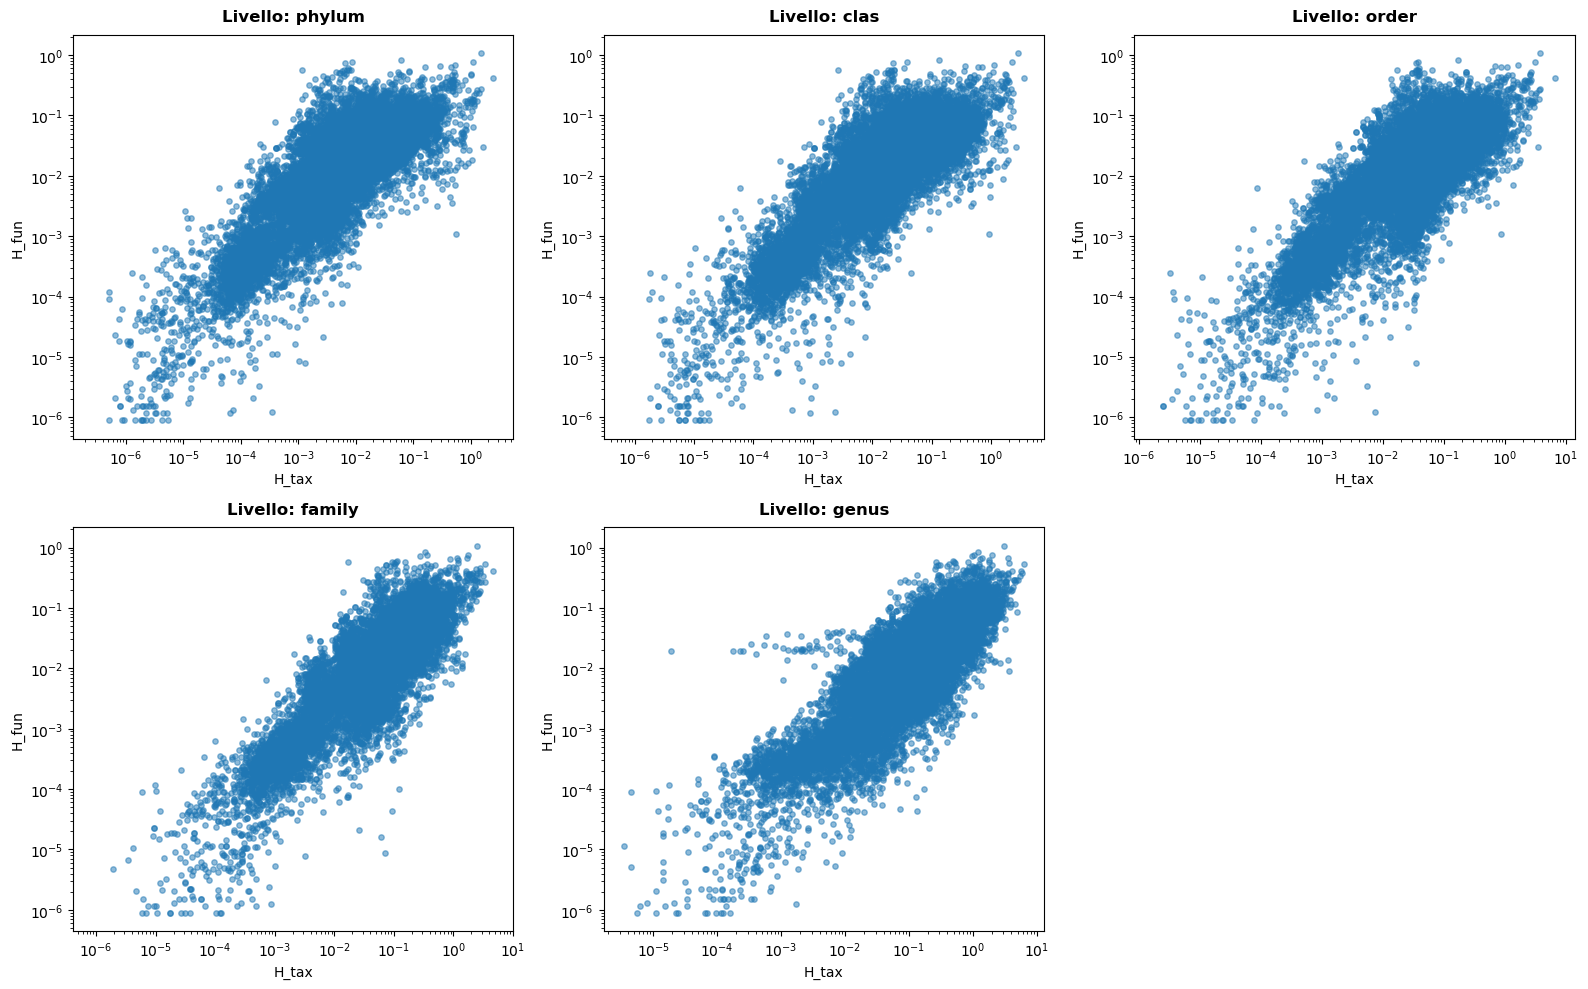

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, livello in enumerate(taxo):
    ax = axes[i]

    df_scatter = pd.DataFrame({
        'H_tax': Hsp[livello],
        'H_fun': Hsf
    }).dropna()

    ax.scatter(df_scatter['H_tax'], df_scatter['H_fun'], alpha=0.5, s=15)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('H_tax', fontsize=10)
    ax.set_ylabel('H_fun', fontsize=10)
    ax.set_title(f'Livello: {livello}', fontsize=12, fontweight='bold', pad=10)

# nasconde eventuali assi vuoti se len(taxo) < numero di subplot
for j in range(len(taxo), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
#plt.savefig('Htax_vs_Hfun_per_livello.png', dpi=150)
plt.show()

In [15]:
meta = pd.read_csv('emp_qiime_mapping_release1.tsv', sep='\t', index_col=0, low_memory=False)

# controlla i valori esatti disponibili
print(meta['empo_2'].unique())

['Animal' 'Non-saline' 'Saline' 'Positive' 'Plant' 'Negative']


In [16]:
gruppi_da_escludere = ['Positive', 'Negative']

indici_da_droppare = meta[meta['empo_2'].isin(gruppi_da_escludere)].index
meta = meta.drop(index=indici_da_droppare)

Campioni totali prima: 27406
Campioni totali dopo esclusione: 27406
Gruppi rimasti: ['Animal' 'Non-saline' 'Saline' 'Plant']


Gruppi trovati: ['Animal', 'Non-saline', 'Saline', 'Plant']
Animal               | campioni tot: 10665 | con H_fun valida: 6071
Non-saline           | campioni tot: 12641 | con H_fun valida: 8588
Saline               | campioni tot:  1551 | con H_fun valida: 953
Plant                | campioni tot:  2549 | con H_fun valida: 1812


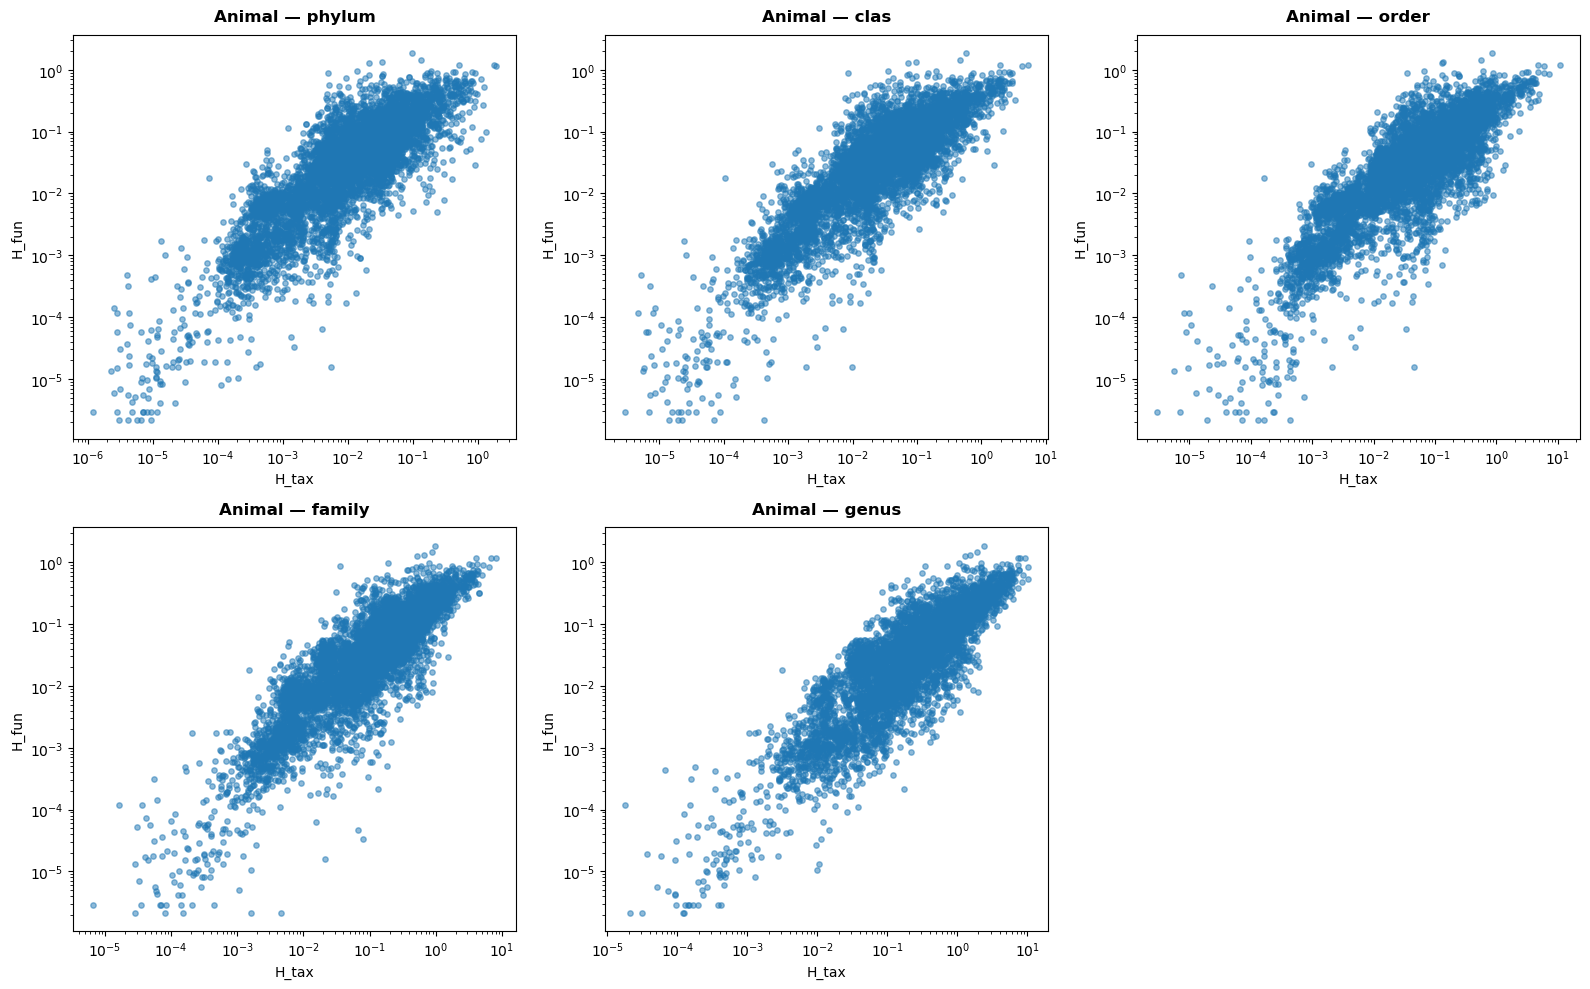

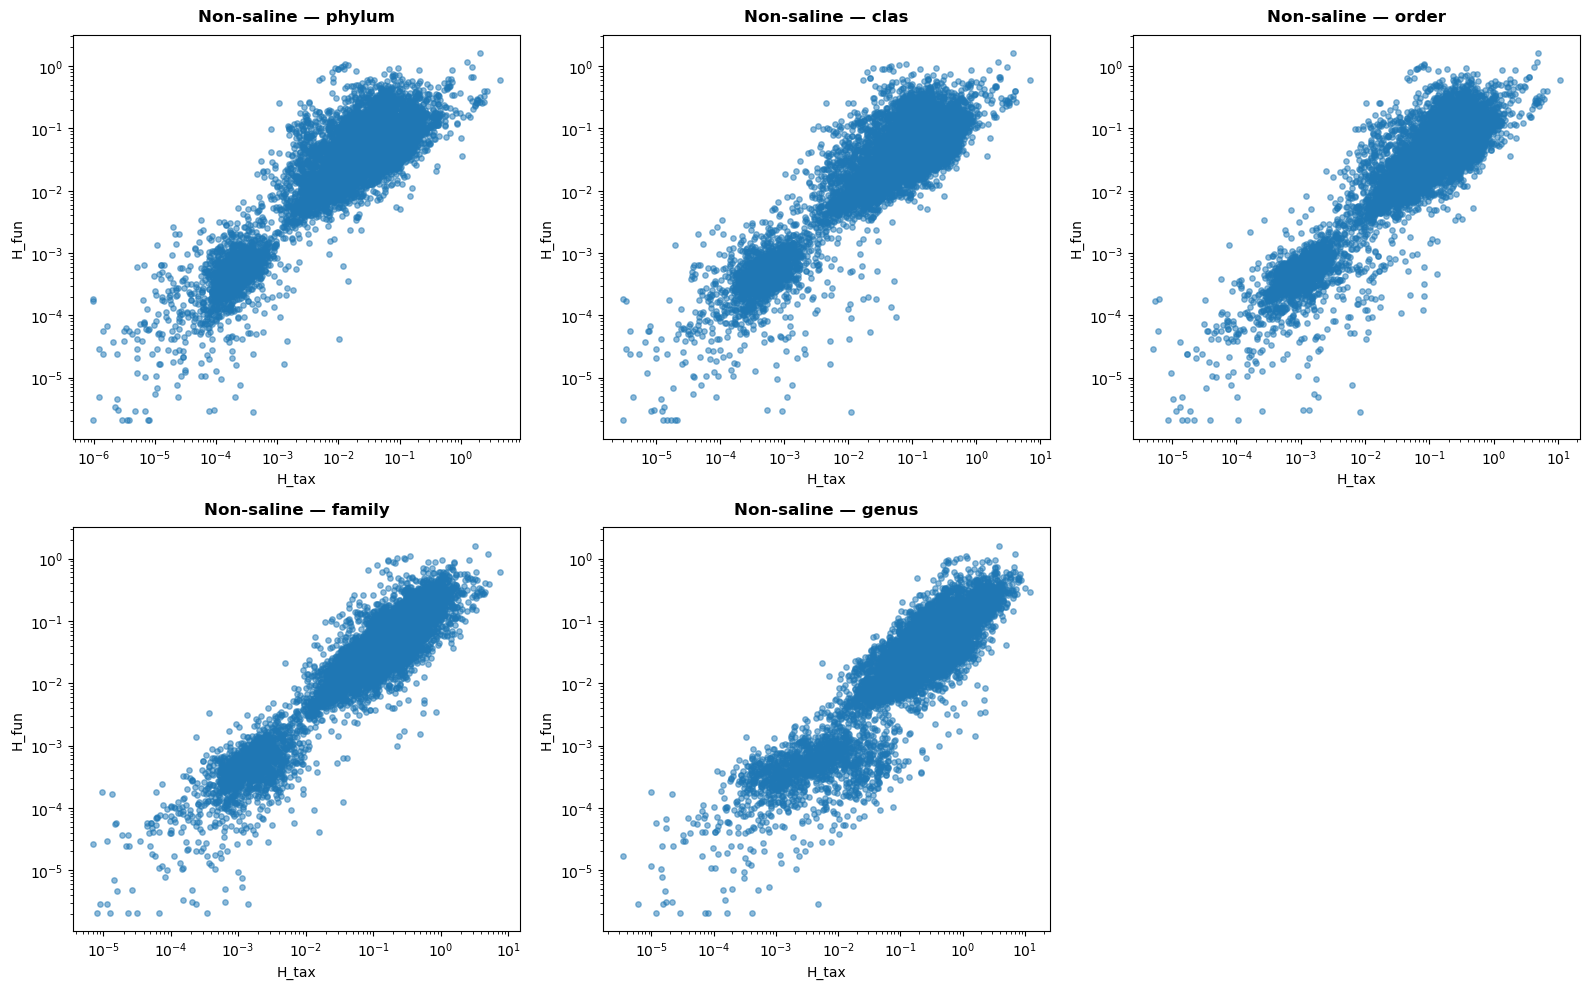

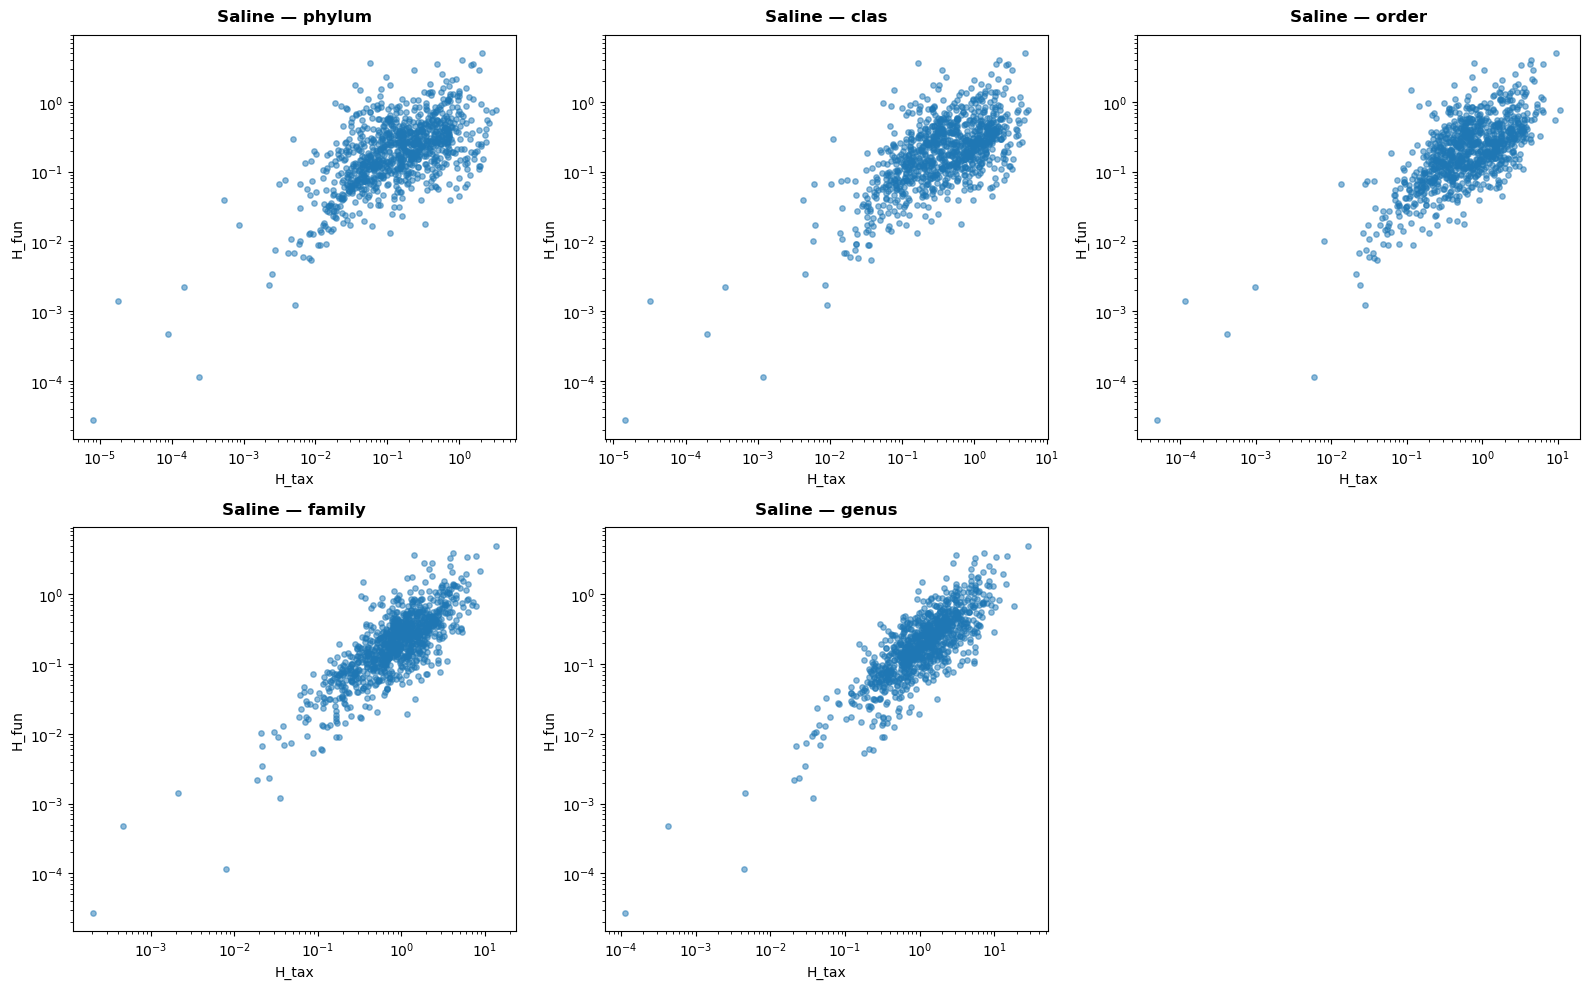

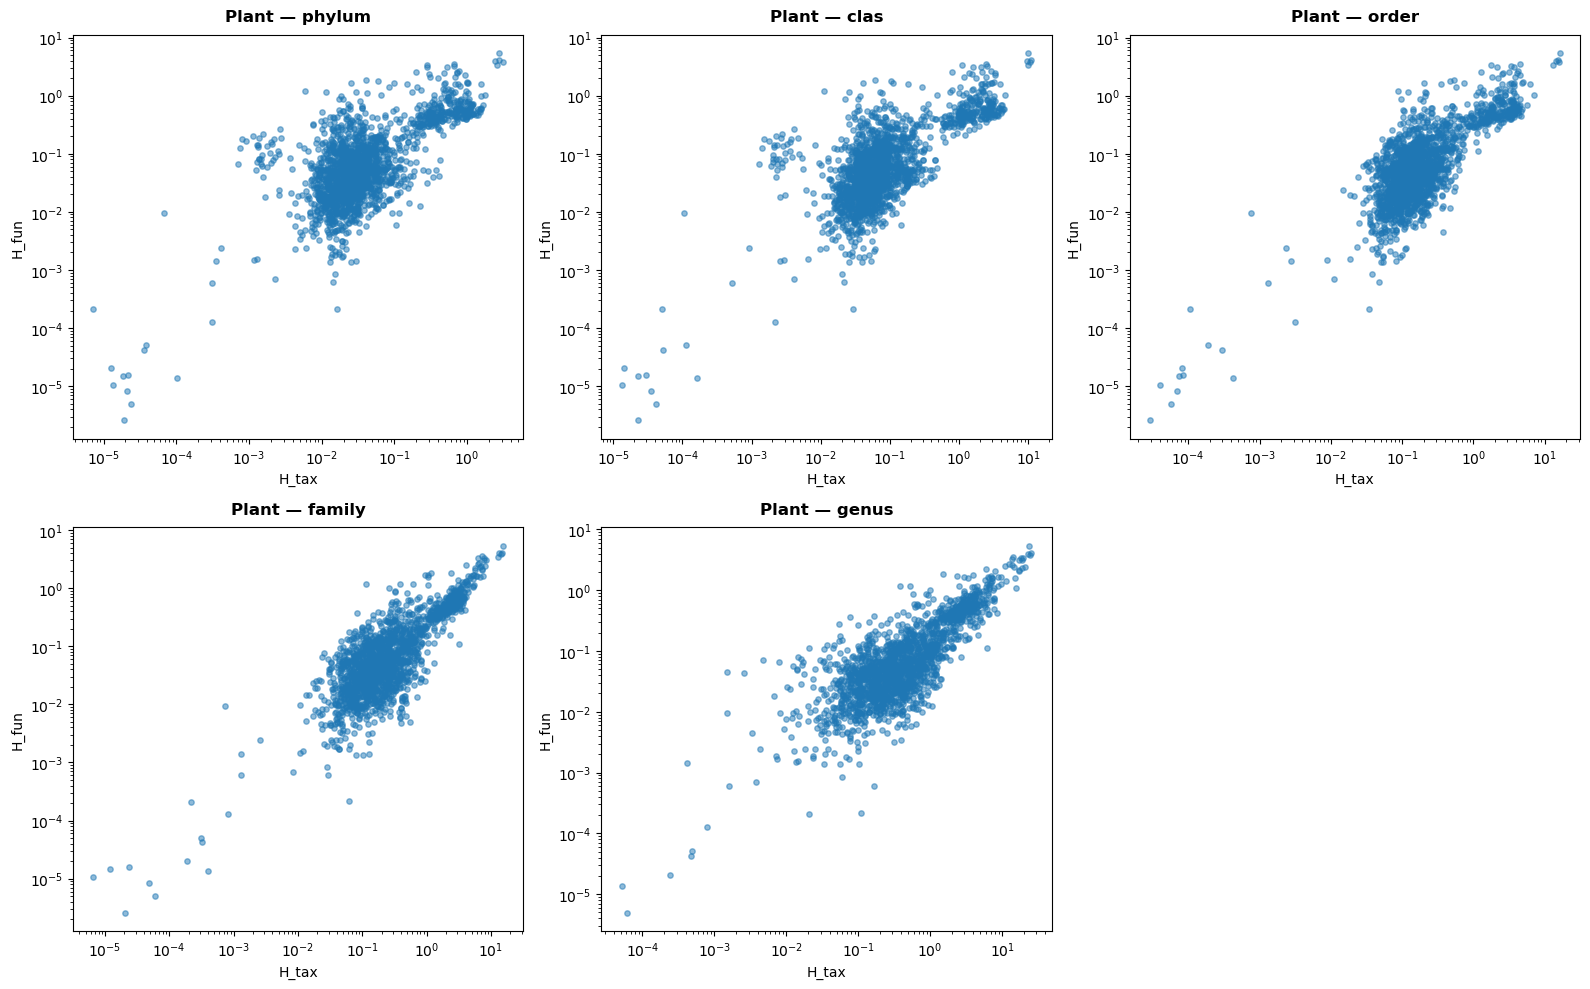

In [18]:
# --- Definisci i gruppi empo_2 e i relativi sample_id ---
gruppi_empo = meta['empo_2'].dropna().unique().tolist()
print("Gruppi trovati:", gruppi_empo)

campioni_per_gruppo = {
    gruppo: meta[meta['empo_2'] == gruppo].index
    for gruppo in gruppi_empo
}

# --- Ricalcola Hsp e Hsf per ciascun gruppo, ristretti ai campioni del gruppo ---
Hsp_gruppo = {}
Hsf_gruppo = {}

for gruppo in gruppi_empo:
    campioni = campioni_per_gruppo[gruppo]

    Hsp_gruppo[gruppo] = {}
    for livello in taxo:
        sub_X = X_sb[livello].loc[X_sb[livello].index.intersection(campioni)]
        sub_X = sub_X.loc[sub_X.sum(axis=1) > 0]
        _, Hs = entropy(sub_X)
        Hsp_gruppo[gruppo][livello] = Hs

    sub_Xf = X_sf.loc[X_sf.index.intersection(campioni)]
    sub_Xf = sub_Xf.loc[sub_Xf.sum(axis=1) > 0]
    _, Hsf = entropy(sub_Xf)
    Hsf_gruppo[gruppo] = Hsf

# --- Scatterplot: una figura per gruppo, griglia sui livelli tassonomici ---
for gruppo in gruppi_empo:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, livello in enumerate(taxo):
        ax = axes[i]

        df_scatter = pd.DataFrame({
            'H_tax': Hsp_gruppo[gruppo][livello],
            'H_fun': Hsf_gruppo[gruppo]
        }).dropna()

        ax.scatter(df_scatter['H_tax'], df_scatter['H_fun'], alpha=0.5, s=15)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('H_tax', fontsize=10)
        ax.set_ylabel('H_fun', fontsize=10)
        ax.set_title(f'{gruppo} — {livello}', fontsize=12, fontweight='bold', pad=10)

    for j in range(len(taxo), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    #plt.savefig(f'Htax_vs_Hfun_{gruppo.replace(" ", "_")}.png', dpi=150)
    plt.show()

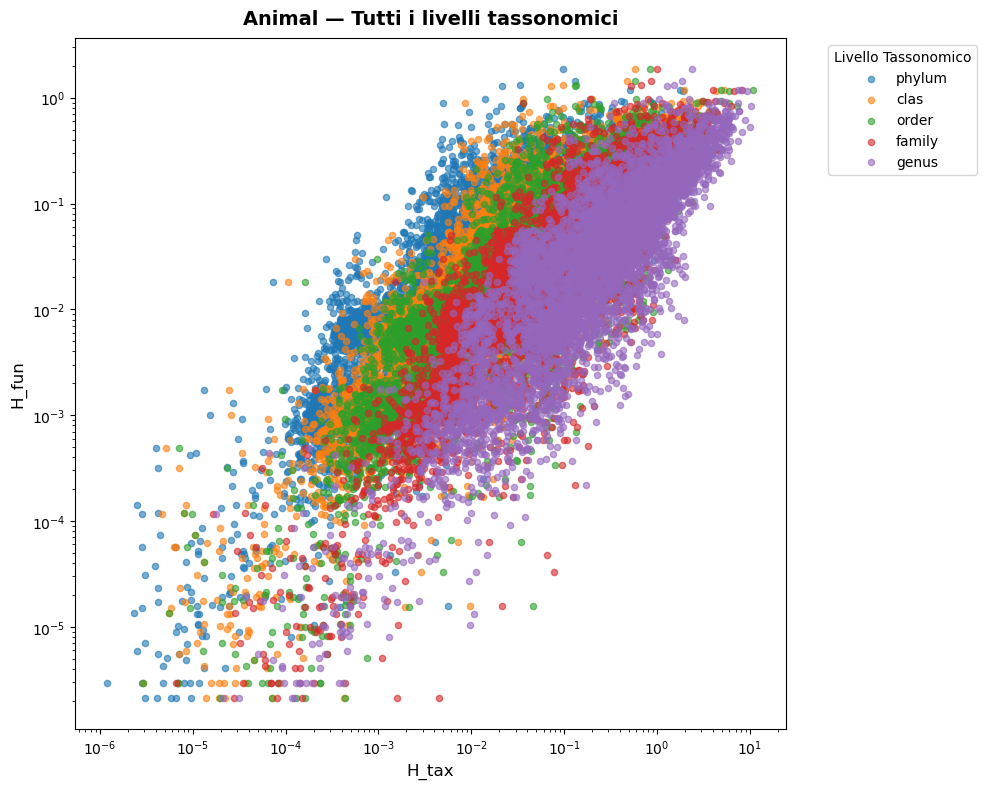

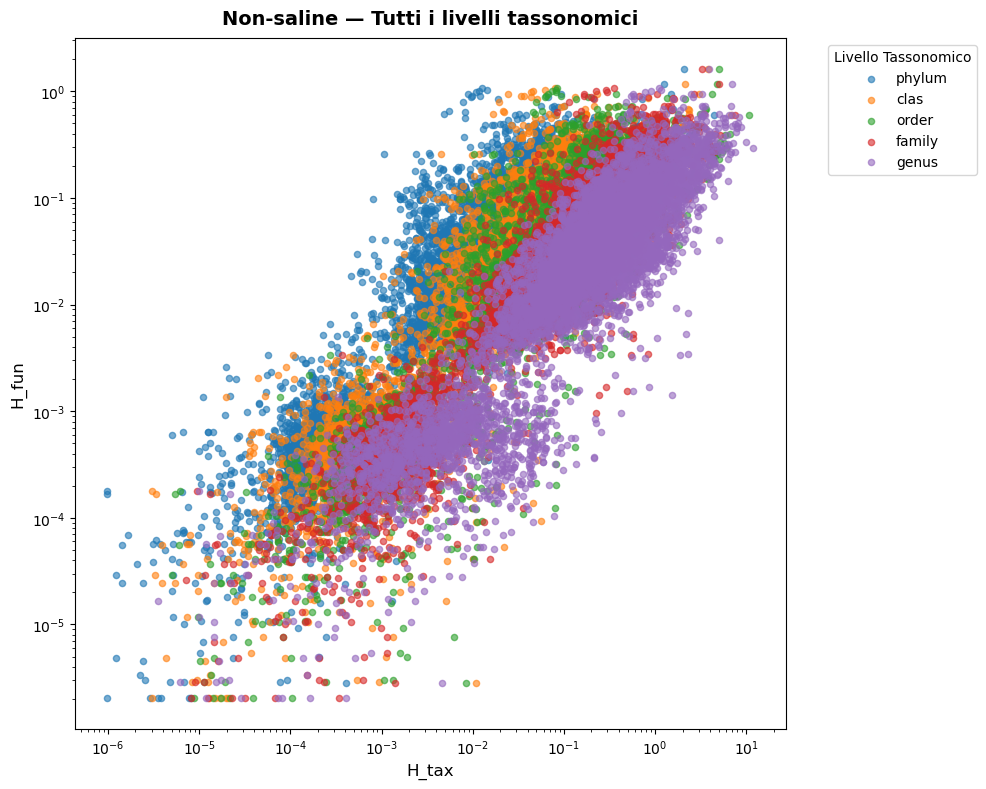

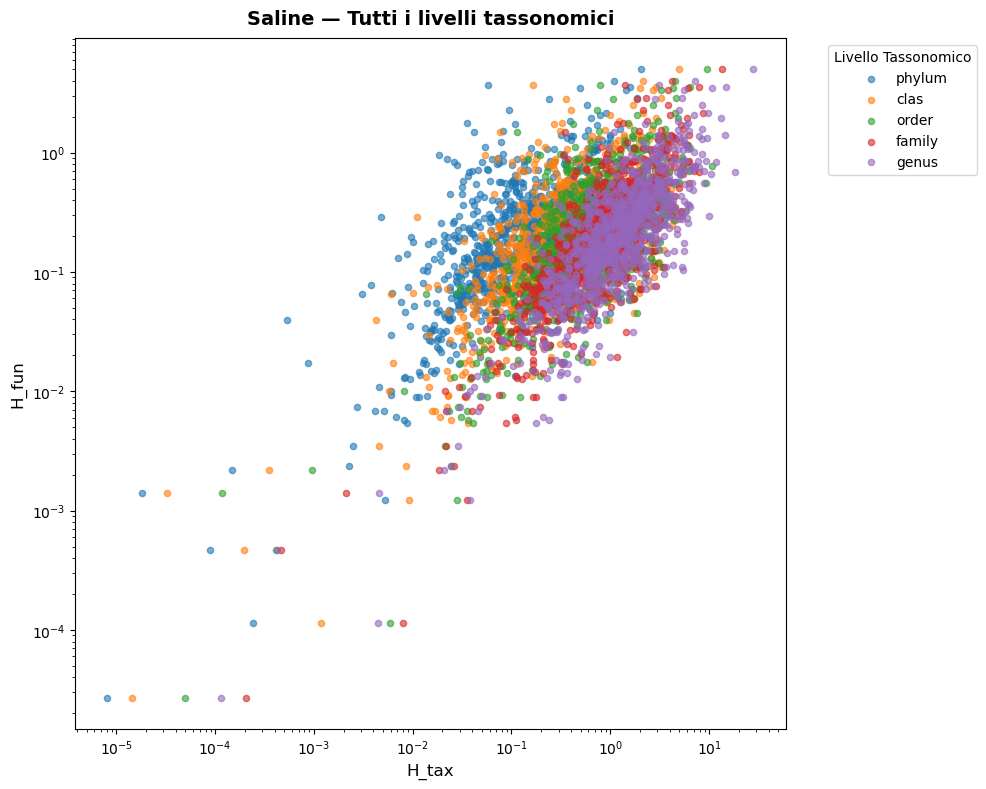

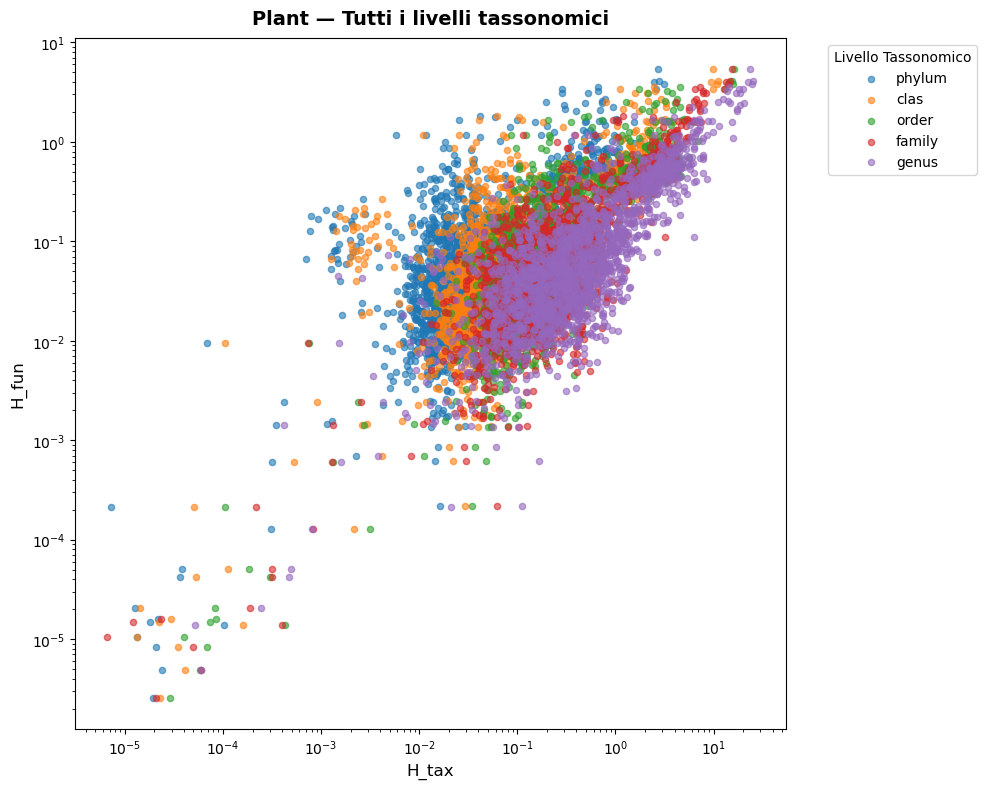

In [19]:
# --- Scatterplot: una figura per gruppo, tutti i livelli sullo stesso grafico ---
for gruppo in gruppi_empo:
    # Creiamo un singolo grafico (1 asse) per gruppo
    fig, ax = plt.subplots(figsize=(10, 8))

    for livello in taxo:
        df_scatter = pd.DataFrame({
            'H_tax': Hsp_gruppo[gruppo][livello],
            'H_fun': Hsf_gruppo[gruppo]
        }).dropna()

        # Disegniamo lo scatterplot sullo stesso 'ax'
        # Aggiungiamo 'label=livello' per popolare la legenda
        ax.scatter(df_scatter['H_tax'], df_scatter['H_fun'], 
                   alpha=0.6, s=20, label=livello)

    # Impostazioni degli assi e del titolo
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('H_tax', fontsize=12)
    ax.set_ylabel('H_fun', fontsize=12)
    ax.set_title(f'{gruppo} — Tutti i livelli tassonomici', fontsize=14, fontweight='bold', pad=10)

    # Aggiungiamo la legenda posizionandola esternamente per non coprire i dati
    ax.legend(title="Livello Tassonomico", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    # plt.savefig(f'Htax_vs_Hfun_combined_{gruppo.replace(" ", "_")}.png', dpi=150)
    plt.show()